# Adapting a structured three-body model to STARK

This notebook is a guided walk-through of the STARK workflow.

The premise is that we already have a small simulation written in a natural, structured style: a `Body` has position, velocity, and mass, and a `ThreeBodySystem` has three named bodies. We do not want to flatten that model just to use an ODE solver.

We will:

- start from the user's existing dataclass model and inverse-square force code
- try the user's fixed-step Euler integrator at two different time steps
- use Moore's equal-mass figure-eight orbit as a qualitative check
- add the small STARK adapter layer: `Translation`, `Workbench`, and derivative
- audit the adapter
- integrate adaptively while asking STARK for evenly spaced plot checkpoints

## Imports and constants

The constants below use Moore's classic equal-mass figure-eight solution (Moore, Phys. Rev. Lett. 70, 3675 (1993)). In the exact dynamics the three bodies chase each other around one shared figure-eight curve. That makes a useful visual test: if a numerical method is too crude, the bodies drift away from the shared orbit.

We integrate for four periods, which gives the tighter Euler run enough time to reveal its drift.

In [1]:
from __future__ import annotations

from copy import deepcopy
from dataclasses import dataclass
from math import sqrt

import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray

from stark import Marcher, Auditor, Executor, Integrator, Interval, Tolerance
from stark.schemes import SchemeDormandPrince


G = 1.0
FIGURE_EIGHT_PERIOD = 6.3259
RUN_PERIODS = 4
STOP_TIME = RUN_PERIODS * FIGURE_EIGHT_PERIOD
CHECKPOINTS_PER_PERIOD = 600
CHECKPOINTS = RUN_PERIODS * CHECKPOINTS_PER_PERIOD
EULER_COARSE_DT = 0.01
EULER_FINE_DT = 0.001
STARK_INITIAL_STEP = 0.02
STARK_TOLERANCE = Tolerance(atol=1.0e-9, rtol=1.0e-9)

## 1. The user's existing model

Here is the kind of model a user may already have. It is structured around domain concepts, not around one solver-friendly vector.

STARK's job is to adapt to this shape, not replace it.

In [2]:
@dataclass(slots=True)
class Body:
    position: NDArray[np.float64]
    velocity: NDArray[np.float64]
    mass: float


@dataclass(slots=True)
class ThreeBodySystem:
    first: Body
    second: Body
    third: Body

    def bodies(self) -> tuple[Body, Body, Body]:
        return self.first, self.second, self.third

    def __repr__(self) -> str:
        return "ThreeBodySystem(bodies=3)"

    __str__ = __repr__

## 2. Existing physics and Euler stepping

The user's physics code computes inverse-square accelerations.

For bodies with positions $r_i$ and masses $m_i$, the acceleration of body $i$ is

$$
a_i = \sum_{j \ne i} G m_j \frac{r_j - r_i}{\|r_j - r_i\|^3}.
$$

The user's first integrator is a simple Euler step:

$$
r_{n+1} = r_n + \Delta t\,v_n, \qquad
v_{n+1} = v_n + \Delta t\,a(r_n).
$$

This is clear code, but it is a fragile method for a chaotic system. Small numerical errors behave like small perturbations of the initial condition, and this problem is very sensitive to those perturbations.

In [3]:
class ThreeBodyDynamics:
    def __repr__(self) -> str:
        return "ThreeBodyDynamics(G=1.0)"

    __str__ = __repr__

    def accelerations(self, system: ThreeBodySystem) -> tuple[NDArray[np.float64], NDArray[np.float64], NDArray[np.float64]]:
        bodies = system.bodies()
        accelerations = [np.zeros(2, dtype=np.float64) for _body in bodies]

        for i, body in enumerate(bodies):
            for j, other in enumerate(bodies):
                if i == j:
                    continue
                displacement = other.position - body.position
                distance_squared = float(np.dot(displacement, displacement))
                distance = sqrt(distance_squared)
                accelerations[i] += G * other.mass * displacement / (distance_squared * distance)

        return accelerations[0], accelerations[1], accelerations[2]

    def euler_step(self, system: ThreeBodySystem, dt: float) -> None:
        accelerations = self.accelerations(system)
        for body, acceleration in zip(system.bodies(), accelerations, strict=True):
            body.position += dt * body.velocity
            body.velocity += dt * acceleration

## 3. Initial condition and trajectory recorder

The initial condition below is Moore's figure-eight orbit. The exact solution has all three bodies on the same curve, separated in phase.

The `ThreeBodyTrajectory` class is ordinary user-side observation code. It depends on a matplotlib axis supplied by the caller, so we can compose plots without baking a comparison routine into the trajectory object.

In [4]:
figure_eight_initial = ThreeBodySystem(
    first=Body(
        position=np.array([-0.97000436, 0.24308753], dtype=np.float64),
        velocity=np.array([0.4662036850, 0.4323657300], dtype=np.float64),
        mass=1.0,
    ),
    second=Body(
        position=np.array([0.97000436, -0.24308753], dtype=np.float64),
        velocity=np.array([0.4662036850, 0.4323657300], dtype=np.float64),
        mass=1.0,
    ),
    third=Body(
        position=np.array([0.0, 0.0], dtype=np.float64),
        velocity=np.array([-0.93240737, -0.86473146], dtype=np.float64),
        mass=1.0,
    ),
)


class ThreeBodyTrajectory:
    def __init__(self, label: str) -> None:
        self.label = label
        self.first: list[NDArray[np.float64]] = []
        self.second: list[NDArray[np.float64]] = []
        self.third: list[NDArray[np.float64]] = []

    def __repr__(self) -> str:
        return f"ThreeBodyTrajectory(label={self.label!r}, samples={len(self.first)})"

    __str__ = __repr__

    def record(self, system: ThreeBodySystem) -> None:
        self.first.append(system.first.position.copy())
        self.second.append(system.second.position.copy())
        self.third.append(system.third.position.copy())

    def plot(
        self,
        axis,
        *,
        body: int,
        color: str,
        label: str,
        linestyle: str = "-",
        alpha: float = 1.0,
        linewidth: float = 1.5,
    ) -> None:
        path = (self.first, self.second, self.third)[body]
        points = np.asarray(path)
        axis.plot(
            points[:, 0],
            points[:, 1],
            color=color,
            linestyle=linestyle,
            alpha=alpha,
            linewidth=linewidth,
            label=label,
        )

## 4. Euler with two time steps

Before adding STARK, try the existing Euler driver with two fixed time steps over four periods. The known figure-eight shape tells us what should happen: all three bodies should sit on one shared curve. If the numerical method is poor, the orbit visibly drifts.

In [5]:
def run_euler(dt: float, checkpoints: int, label: str) -> tuple[ThreeBodyTrajectory, int]:
    dynamics = ThreeBodyDynamics()
    system = deepcopy(figure_eight_initial)
    trajectory = ThreeBodyTrajectory(label)
    trajectory.record(system)

    steps = 0
    next_checkpoint = STOP_TIME / checkpoints
    while steps * dt < STOP_TIME:
        dynamics.euler_step(system, min(dt, STOP_TIME - steps * dt))
        steps += 1
        time = min(steps * dt, STOP_TIME)
        if time + 1.0e-12 >= next_checkpoint:
            trajectory.record(system)
            next_checkpoint += STOP_TIME / checkpoints

    return trajectory, steps


coarse_euler, coarse_steps = run_euler(EULER_COARSE_DT, CHECKPOINTS, f"Euler dt={EULER_COARSE_DT:g}")
fine_euler, fine_steps = run_euler(EULER_FINE_DT, CHECKPOINTS, f"Euler dt={EULER_FINE_DT:g}")

coarse_steps, fine_steps

(2531, 25304)

Text(0.5, 0.98, 'The same model, integrated with two Euler time steps')

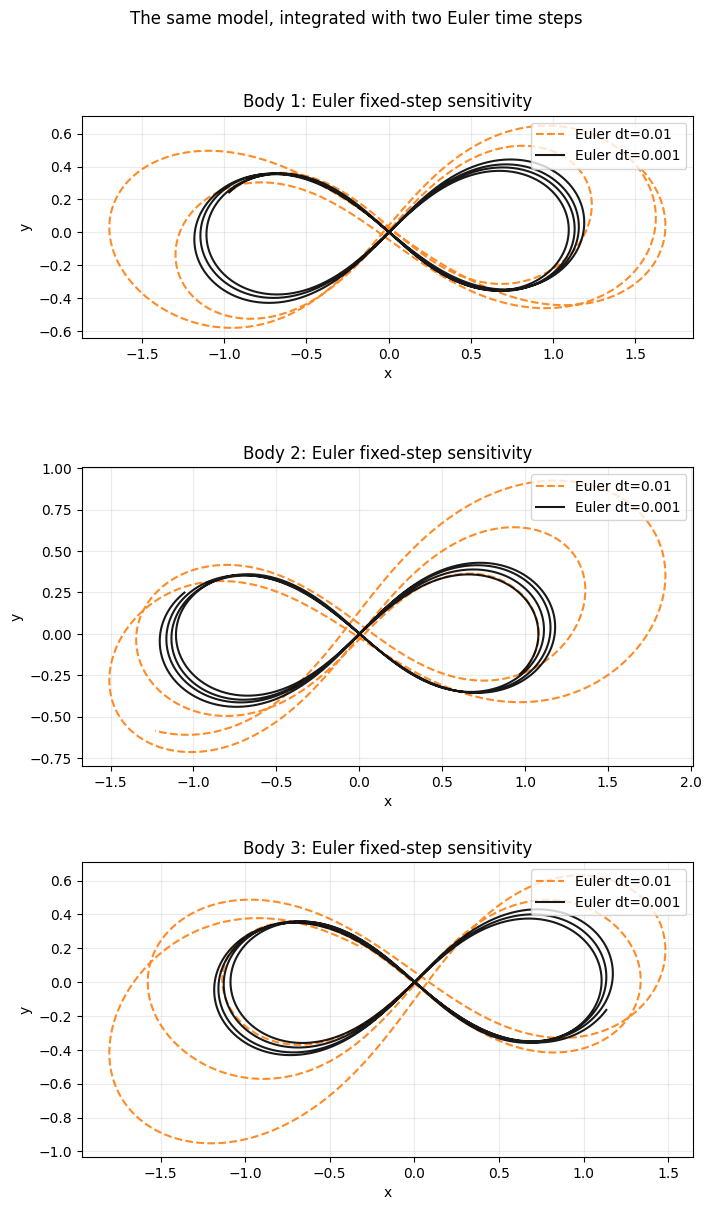

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(7, 12), constrained_layout=True)

for body_index, axis in enumerate(axes):
    coarse_euler.plot(
        axis,
        body=body_index,
        color="tab:orange",
        linestyle="--",
        label=f"Euler dt={EULER_COARSE_DT:g}",
        alpha=0.9,
    )
    fine_euler.plot(
        axis,
        body=body_index,
        color="black",
        label=f"Euler dt={EULER_FINE_DT:g}",
        alpha=0.9,
    )
    axis.set_title(f"Body {body_index + 1}: Euler fixed-step sensitivity")
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    axis.grid(True, alpha=0.25)
    axis.legend(loc="upper right")

fig.suptitle("The same model, integrated with two Euler time steps")

The plot above is the point where the existing method fails the known problem. Moore's initial condition should produce one shared figure-eight curve, but the Euler trajectories depend strongly on the chosen fixed step and drift away from the expected dynamics. This is exactly the kind of failure we expect in a chaotic system: local truncation error accumulates, behaves like a perturbation to the state, and eventually sends the trajectory somewhere visibly different. That failure is the motivation for keeping the user's model while replacing only the stepping machinery.


## 5. The STARK translation

STARK separates a rich mutable state from a linear translation object.

For this model, a translation is not another `ThreeBodySystem`. It is the change to each body's position and velocity. Runge-Kutta schemes can add and scale these translations while leaving the user's structured model intact.

In [7]:
@dataclass(slots=True)
class ThreeBodyTranslation:
    first_position: NDArray[np.float64]
    first_velocity: NDArray[np.float64]
    second_position: NDArray[np.float64]
    second_velocity: NDArray[np.float64]
    third_position: NDArray[np.float64]
    third_velocity: NDArray[np.float64]

    def __repr__(self) -> str:
        return f"ThreeBodyTranslation(norm={self.norm():.6g})"

    __str__ = __repr__

    def __call__(self, origin: ThreeBodySystem, result: ThreeBodySystem) -> None:
        result.first.position[:] = origin.first.position + self.first_position
        result.first.velocity[:] = origin.first.velocity + self.first_velocity
        result.second.position[:] = origin.second.position + self.second_position
        result.second.velocity[:] = origin.second.velocity + self.second_velocity
        result.third.position[:] = origin.third.position + self.third_position
        result.third.velocity[:] = origin.third.velocity + self.third_velocity

    def norm(self) -> float:
        total = 0.0
        for vector in (
            self.first_position,
            self.first_velocity,
            self.second_position,
            self.second_velocity,
            self.third_position,
            self.third_velocity,
        ):
            total += float(np.dot(vector, vector))
        return sqrt(total)

    def __add__(self, other: ThreeBodyTranslation) -> ThreeBodyTranslation:
        return ThreeBodyTranslation(
            self.first_position + other.first_position,
            self.first_velocity + other.first_velocity,
            self.second_position + other.second_position,
            self.second_velocity + other.second_velocity,
            self.third_position + other.third_position,
            self.third_velocity + other.third_velocity,
        )

    def __rmul__(self, scalar: float) -> ThreeBodyTranslation:
        return ThreeBodyTranslation(
            scalar * self.first_position,
            scalar * self.first_velocity,
            scalar * self.second_position,
            scalar * self.second_velocity,
            scalar * self.third_position,
            scalar * self.third_velocity,
        )

## 6. The STARK workbench

The workbench tells STARK how to allocate and copy the user's objects. This is deliberately explicit: STARK should not guess how to construct a valid `ThreeBodySystem` or how to copy its arrays.

In [8]:
class ThreeBodyWorkbench:
    def __repr__(self) -> str:
        return "ThreeBodyWorkbench(bodies=3, dimensions=2)"

    __str__ = __repr__

    def allocate_state(self) -> ThreeBodySystem:
        return ThreeBodySystem(
            first=Body(np.zeros(2, dtype=np.float64), np.zeros(2, dtype=np.float64), 1.0),
            second=Body(np.zeros(2, dtype=np.float64), np.zeros(2, dtype=np.float64), 1.0),
            third=Body(np.zeros(2, dtype=np.float64), np.zeros(2, dtype=np.float64), 1.0),
        )

    def copy_state(self, dst: ThreeBodySystem, src: ThreeBodySystem) -> None:
        for dst_body, src_body in zip(dst.bodies(), src.bodies(), strict=True):
            dst_body.position[:] = src_body.position
            dst_body.velocity[:] = src_body.velocity
            dst_body.mass = src_body.mass

    def allocate_translation(self) -> ThreeBodyTranslation:
        return ThreeBodyTranslation(
            first_position=np.zeros(2, dtype=np.float64),
            first_velocity=np.zeros(2, dtype=np.float64),
            second_position=np.zeros(2, dtype=np.float64),
            second_velocity=np.zeros(2, dtype=np.float64),
            third_position=np.zeros(2, dtype=np.float64),
            third_velocity=np.zeros(2, dtype=np.float64),
        )

## 7. The derivative adapter

This is where the existing physics enters STARK.

The derivative of position is velocity. The derivative of velocity is acceleration. The acceleration is still computed by the user's original `ThreeBodyDynamics` code.

In [9]:
class ThreeBodyDerivative:
    def __init__(self, dynamics: ThreeBodyDynamics) -> None:
        self.dynamics = dynamics

    def __repr__(self) -> str:
        return f"ThreeBodyDerivative(dynamics={self.dynamics!r})"

    __str__ = __repr__

    def __call__(self, interval: Interval, state: ThreeBodySystem, out: ThreeBodyTranslation) -> None:
        del interval
        first_acceleration, second_acceleration, third_acceleration = self.dynamics.accelerations(state)

        out.first_position[:] = state.first.velocity
        out.first_velocity[:] = first_acceleration
        out.second_position[:] = state.second.velocity
        out.second_velocity[:] = second_acceleration
        out.third_position[:] = state.third.velocity
        out.third_velocity[:] = third_acceleration

## 8. Audit the interface

Before running a real solve, ask STARK to audit the objects we just wrote. The audit is a checklist: does the derivative look callable, can the workbench allocate and copy, can the translation be applied and measured?

In [10]:
dynamics = ThreeBodyDynamics()
derivative = ThreeBodyDerivative(dynamics)
workbench = ThreeBodyWorkbench()
audit_scheme = SchemeDormandPrince(derivative, workbench)
audit_state = deepcopy(figure_eight_initial)
audit_interval = Interval(present=0.0, step=STARK_INITIAL_STEP, stop=STOP_TIME)

audit = Auditor(
    state=audit_state,
    derivative=derivative,
    translation=workbench.allocate_translation(),
    workbench=workbench,
    interval=audit_interval,
    scheme=audit_scheme,
    tolerance=STARK_TOLERANCE,
)
print(audit)
audit.raise_if_invalid()

STARK audit checklist
Object      | Required behavior                                        | Present
------------+----------------------------------------------------------+--------
Interval    | Interval provides present                                | yes    
Interval    | Interval provides step                                   | yes    
Interval    | Interval provides stop                                   | yes    
Interval    | Interval provides increment(dt)                          | yes    
Interval    | Interval provides copy()                                 | yes    
Interval    | Interval.copy() succeeds                                 | yes    
Interval    | Interval.copy() preserves present, step, and stop        | yes    
Interval    | Interval.increment(dt) advances present on a copy        | yes    
Derivative  | Derivative is callable                                   | yes    
Derivative  | Derivative(interval, state, translation) can be called   | yes    
Transl

## 9. Integrate adaptively with checkpoints

Now the user gets adaptive stepping without changing the original model.

STARK includes several prebuilt adaptive Runge-Kutta schemes, and the same contracts also let users provide their own schemes. For this example we will use Dormand-Prince, a common embedded 5(4) method.

The `Executor` carries runtime policy such as tolerance, so the marcher now owns a scheme together with an executor rather than a bare tolerance object.

The `checkpoints` argument asks STARK to pass through evenly spaced output times. This is ideal for plots and animations: the solver can adapt internally, while the trajectory recorder receives display-ready snapshots.

In [11]:
dynamics = ThreeBodyDynamics()
derivative = ThreeBodyDerivative(dynamics)
workbench = ThreeBodyWorkbench()
state = deepcopy(figure_eight_initial)
interval = Interval(present=0.0, step=STARK_INITIAL_STEP, stop=STOP_TIME)

scheme = SchemeDormandPrince(derivative, workbench)
executor = Executor(tolerance=STARK_TOLERANCE)
marcher = Marcher(scheme, executor)
integrate = Integrator(executor=executor)
stark_trajectory = ThreeBodyTrajectory("STARK RKDP")
stark_trajectory.record(state)

checkpoint_outputs = 0
for _checkpoint_interval, checkpoint_state in integrate.live(
    marcher,
    interval,
    state,
    checkpoints=CHECKPOINTS,
):
    checkpoint_outputs += 1
    stark_trajectory.record(checkpoint_state)

checkpoint_outputs

2400

## 10. Compare the trajectories body by body

Each row below is one body. The left column shows how Euler changes when the fixed step changes. The right column compares the fine Euler path against the adaptive STARK result at the same plot checkpoints.

Because this initial condition should produce one shared figure-eight curve, disagreement is easy to interpret: it is numerical error, not a new physical behavior.

Text(0.5, 0.98, 'Adapting a structured three-body model to STARK')

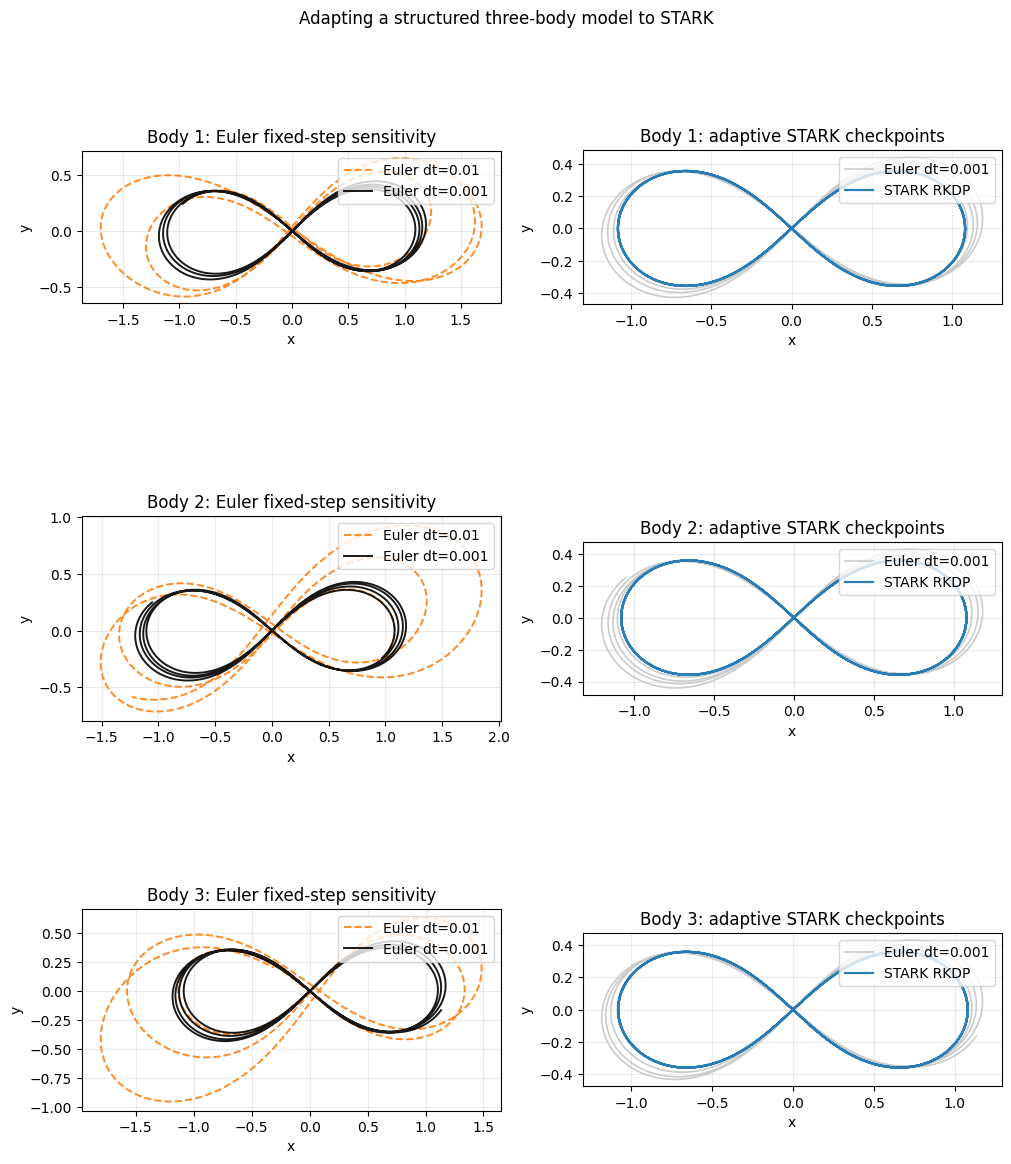

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12), constrained_layout=True)

for body_index in range(3):
    euler_axis = axes[body_index, 0]
    stark_axis = axes[body_index, 1]

    coarse_euler.plot(
        euler_axis,
        body=body_index,
        color="tab:orange",
        linestyle="--",
        label=f"Euler dt={EULER_COARSE_DT:g}",
        alpha=0.9,
        linewidth=1.4,
    )
    fine_euler.plot(
        euler_axis,
        body=body_index,
        color="black",
        label=f"Euler dt={EULER_FINE_DT:g}",
        alpha=0.9,
        linewidth=1.4,
    )
    euler_axis.set_title(f"Body {body_index + 1}: Euler fixed-step sensitivity")
    euler_axis.legend(loc="upper right")

    fine_euler.plot(
        stark_axis,
        body=body_index,
        color="0.75",
        label=f"Euler dt={EULER_FINE_DT:g}",
        alpha=0.8,
        linewidth=1.2,
    )
    stark_trajectory.plot(
        stark_axis,
        body=body_index,
        color="tab:blue",
        label="STARK RKDP",
        alpha=0.95,
        linewidth=1.6,
    )
    stark_axis.set_title(f"Body {body_index + 1}: adaptive STARK checkpoints")
    stark_axis.legend(loc="upper right")

for axis in axes.ravel():
    axis.set_aspect("equal", adjustable="box")
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    axis.grid(True, alpha=0.25)

fig.suptitle("Adapting a structured three-body model to STARK")

## What changed?

The user's model did not become a flat vector. The physics code was not rewritten. The trajectory recorder still receives structured systems.

The new code is a thin interface layer:

- `ThreeBodyTranslation` tells STARK what a linear update looks like.
- `ThreeBodyWorkbench` tells STARK how to allocate and copy user objects.
- `ThreeBodyDerivative` adapts existing acceleration code to the STARK derivative contract.
- `Executor` carries the runtime policy used by `Marcher` and `Integrator`.
- `Auditor` checks that this interface is complete.
- `Integrator().live(..., checkpoints=...)` gives display-ready samples without forcing the adaptive solver to use a fixed display step.

That is the core STARK pattern: keep the rich state model, add a small contract-conforming adapter, then use adaptive Runge-Kutta schemes on the original objects.